# Advanced Solar Activity Forecasting: Mathematical Framework
### Integration of PVL Parametrics, Adaptive Kalman Filtering, and Dynamic Mode Decomposition (DMD)

This report formalizes the predictive engine used for sunspot number (SSN) and latitudinal migration analysis. We combine physical heuristics based on the Podladchikova-Van der Linden (PVL) model with data-driven operator theory to provide robust forecasts for Solar Cycle 25 and beyond.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Publication Style Configuration
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#334155',
    'grid.alpha': 0.15,
    'font.family': 'serif',
    'legend.frameon': True,
    'legend.edgecolor': '#e2e8f0'
})

COLORS = {'obs': '#64748b', 'kalman': '#10b981', 'dmd': '#8b5cf6', 'future_bg': '#f0fdf4'}

## 1. Discretization and Vectorization via Latitudinal Binning

To analyze the Spörer diagram mathematically, we transform individual sunspot observations into a time-series of state vectors. Let $N_{\text{spots}}(t)$ be the total number of sunspots observed at time $t$, and $\theta_i$ be the heliographic latitude of the $i$-th sunspot. Given the domain $\theta \in [-50^\circ, 50^\circ]$, we define a discretization into $M=25$ bins of size $\Delta \theta = 4^\circ$ using grid points $\theta_j$:

$$V_j(t) = \sum_{i=1}^{N_{\text{spots}}(t)} \mathbb{1}_{\mathcal{B}_j}(\theta_i)$$

where $\mathcal{B}_j = [\theta_j, \theta_{j+1})$ is the $j$-th latitudinal bin and $\mathbb{1}$ is the indicator function. The value $V_j(t)$ thus represents the sunspot density (count) within the $j$-th latitudinal bin.

The complete state of the solar disk at time $t$ is represented by the vector $\mathbf{x}_t = [V_1(t), V_2(t), \dots, V_M(t)]^T \in \mathbb{R}^M$. The collection of $N$ monthly observations forms the snapshot matrix:

$$\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N] \in \mathbb{R}^{M \times N}$$


In [9]:
path = r'labels.csv'
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date_iso'])
df['year_month'] = df['date'].dt.to_period('M')

monthly_hist = df.groupby('year_month').size().reset_index(name='ssn')
monthly_hist['year_float'] = monthly_hist['year_month'].apply(lambda x: x.year + (x.month - 1) / 12)

lat_bins = np.arange(-50, 51, 4)
snapshots = np.zeros((len(lat_bins)-1, len(monthly_hist)))
for j, t in enumerate(monthly_hist['year_month']):
    snapshots[:, j], _ = np.histogram(df[df['year_month'] == t]['lat'], bins=lat_bins)

## 2. Dynamic Mode Decomposition (DMD) Formalism

DMD seeks the best linear operator $\mathbf{A}$ that maps a latitudinal state vector to its successor in time. Given a collection of $N$ observations, we define the snapshot matrices:

$$\mathbf{X}_1 = [\mathbf{x}_1, \dots, \mathbf{x}_{N-1}], \quad \mathbf{X}_2 = [\mathbf{x}_2, \dots, \mathbf{x}_N]$$

We compute the truncated Singular Value Decomposition (SVD) of $\mathbf{X}_1 \approx \mathbf{U}_r \boldsymbol{\Sigma}_r \mathbf{V}_r^H$. The operator is analyzed through the following steps:

1. **Projection**: The state $\mathbf{x}_k$ is projected into a reduced-order state $\tilde{\mathbf{x}}_k = \mathbf{U}_r^H \mathbf{x}_k \in \mathbb{R}^r$.
2. **Reduced Dynamics**: The evolution in the POD subspace is $\tilde{\mathbf{x}}_{k+1} = \tilde{\mathbf{A}} \tilde{\mathbf{x}}_k$, where $\tilde{\mathbf{A}} = \mathbf{U}_r^H \mathbf{X}_2 \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1}$.
3. **Operator Reconstruction**: The full rank-$r$ mapping $\mathbf{A}$ is reconstructed in the original coordinates:
   $$\mathbf{A} \approx \mathbf{X}_2 \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1} \mathbf{U}_r^H$$

This mathematical framework enables the model to both **reconstruct historical dynamics** (via one-step ahead predictions $\hat{\mathbf{x}}_k = \mathbf{A} \mathbf{x}_{k-1}$ for $k \leq N$) and **project future activity** (via iterative forecasting $\mathbf{x}_{k+1} = \mathbf{A} \mathbf{x}_k$ for $k > N$).


In [10]:
X1, X2 = snapshots[:, :-1], snapshots[:, 1:]
U, S, Vh = svd(X1, full_matrices=False)
r = 10
Ur, Sr, Vr = U[:, :r], np.diag(S[:r]), Vh[:r, :].T
A = X2 @ Vr @ np.linalg.inv(Sr) @ Ur.T

HORIZON = 60
dmd_ssn_raw, butterfly_dots = [], []

for t in range(len(monthly_hist)):
    pred_v = snapshots[:, 0] if t == 0 else A @ snapshots[:, t-1]
    pred_v = np.maximum(0, pred_v)
    dmd_ssn_raw.append(np.sum(pred_v))
    if t % 2 == 0:
        for l in range(len(lat_bins)-1):
            if pred_v[l] > 0.5:
                butterfly_dots.append({'y': monthly_hist['year_float'].iloc[t], 'l': lat_bins[l]+2, 's': pred_v[l], 'is_f': False})

curr_v = snapshots[:, -1]
future_yf = [monthly_hist['year_float'].max() + (i+1)/12 for i in range(HORIZON)]
for t in range(HORIZON):
    curr_v = np.maximum(0, (A @ curr_v) * 0.98)
    dmd_ssn_raw.append(np.sum(curr_v))
    if t % 2 == 0:
        for l in range(len(lat_bins)-1):
            if curr_v[l] > 0.5:
                butterfly_dots.append({'y': future_yf[t], 'l': lat_bins[l]+2, 's': curr_v[l], 'is_f': True})

butterfly_df = pd.DataFrame(butterfly_dots)

## 3. Discrete Integral and Scaling (DMD SSN)

The total activity, or DMD-reconstructed Sunspot Number ($SSN_{DMD}$), is obtained by integrating the predicted latitudinal density vector $\hat{\mathbf{x}}_t = [\hat{V}_1(t), \dots, \hat{V}_M(t)]^T$:

$$SSN_{DMD}(t) = \kappa \cdot \sum_{j=1}^M \hat{V}_j(t)$$

The scaling factor $\kappa$ serves as a calibration constant to map the integrated latitudinal counts back to the standard SSN scale. It is computed to minimize bias across the historical record:

$$\kappa = \frac{\sum_{t=1}^N SSN_{obs}(t)}{\sum_{t=1}^N \left( \sum_{j=1}^M \hat{V}_j(t) \right)}$$


In [11]:
kappa = np.sum(monthly_hist['ssn']) / np.sum(dmd_ssn_raw[:len(monthly_hist)])
dmd_ssn = np.array(dmd_ssn_raw) * kappa

## 4. PVL Parametric Model & Adaptive Kalman Filter

To forecast the Sunspot Number (SSN) as a global time series, we combine the **Podladchikova-Van der Linden (PVL)** parametric model with an adaptive Kalman Filter. 

### 4.1. The PVL Cycle Shape
The PVL model (2012) provides a heuristic "skeleton" for the solar cycle. The shape function $f(v)$ is defined as:

$$f(v; a, b) = \frac{a \cdot v^3}{\exp(v^2/b^2) - 0.71}$$

where $v$ is the time in months from cycle onset. The parameters $a$ and $b$ are linked via the power-law: $b = 27.12 + 25.15 \cdot (1000 a)^{-1/4}$. The amplitude $a$ is calibrated iteratively to match a target maximum SSN.

### 4.2. Adaptive Kalman Filter Formalism
We use the PVL curve to guide the state transition of a Kalman Filter. The predicted global activity trend, **$SSN_{PVLK}$**, is defined as the updated state of the filter:

$$SSN_{PVLK}(t) = \hat{x}_k$$

The recursive equations are:
$$\hat{x}_k^- = \Phi_k \hat{x}_{k-1}, \quad \hat{x}_k = \hat{x}_k^- + K_k (z_k - \hat{x}_k^-)$$

where $\Phi_k = f(v_k)/f(v_{k-1})$ and $K_k$ is the Kalman gain. Adaptive noise scaling is employed to account for heteroscedasticity ($Q_k = 0.2 \hat{x}_k^-$, $R_k = 2.5 \hat{x}_k^-$).


In [12]:
def pvl_shape(v, a, b): return (a * (v**3)) / (np.exp((v*v)/(b*b)) - 0.71) if v > 0 else 0.0
a_p, target = 0.01, 140
for _ in range(10): 
    b_p = 27.12 + 25.15 / np.power(a_p * 1000, 0.25)
    a_p *= (target / max(1, pvl_shape(50, a_p, b_p)))
b_p = 27.12 + 25.15 / np.power(a_p * 1000, 0.25)

full_yf = np.concatenate([monthly_hist['year_float'].values, future_yf])
is_f = np.concatenate([np.zeros(len(monthly_hist)), np.ones(HORIZON)]).astype(bool)
def get_v(yf): return max(1, int(round((yf - (2019.9 if yf >= 2019.9 else 2008.9)) * 12)))

kalman_ssn, state_r, state_p = [], monthly_hist['ssn'].iloc[0], 10.0
for yf in full_yf:
    phi = pvl_shape(get_v(yf), a_p, b_p) / max(0.1, pvl_shape(get_v(yf - 1/12), a_p, b_p))
    r_pred = phi * state_r
    state_p = phi**2 * state_p + 0.2 * r_pred
    idx = np.where(monthly_hist['year_float'] == yf)[0]
    if len(idx) > 0:
        k_g = state_p / (state_p + 2.5 * r_pred)
        state_r = r_pred + k_g * (monthly_hist['ssn'].iloc[idx[0]] - r_pred)
        state_p = (1 - k_g) * state_p
    else: state_r = r_pred
    kalman_ssn.append(state_r)

## 5. Temporal Evolution Analysis and Model Comparison

We evaluate the performance of both models by calculating the Mean Absolute Percentage Error (MAPE) against historical observations and generating independent projections. 

The **PVL-Kalman** model ($SSN_{PVLK}$) focuses on optimal scalar tracking, while the **DMD** model ($SSN_{DMD}$) provides a spatio-temporal reconstruction of the butterfly diagram, integrating latitudinal density into a global index.


MAPE PVL-Kalman: 32.14%
MAPE DMD: 44.73%


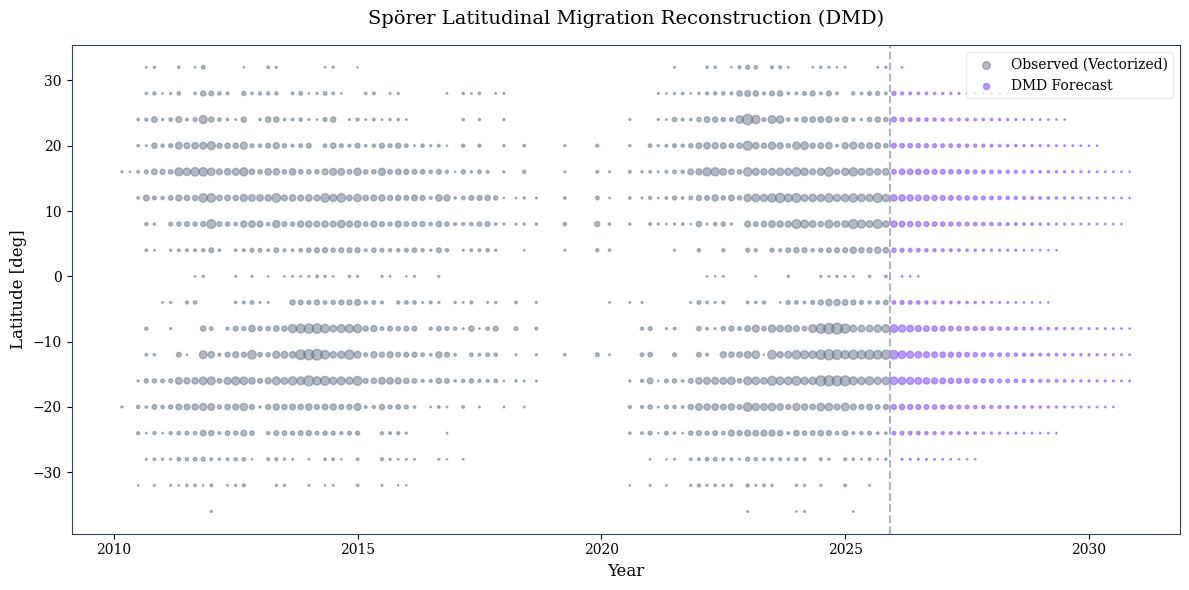

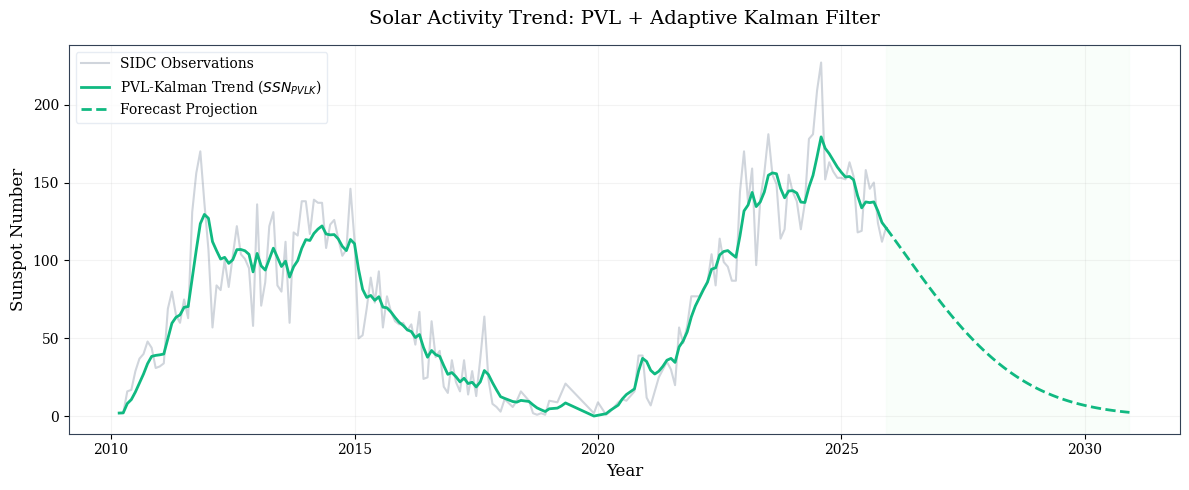

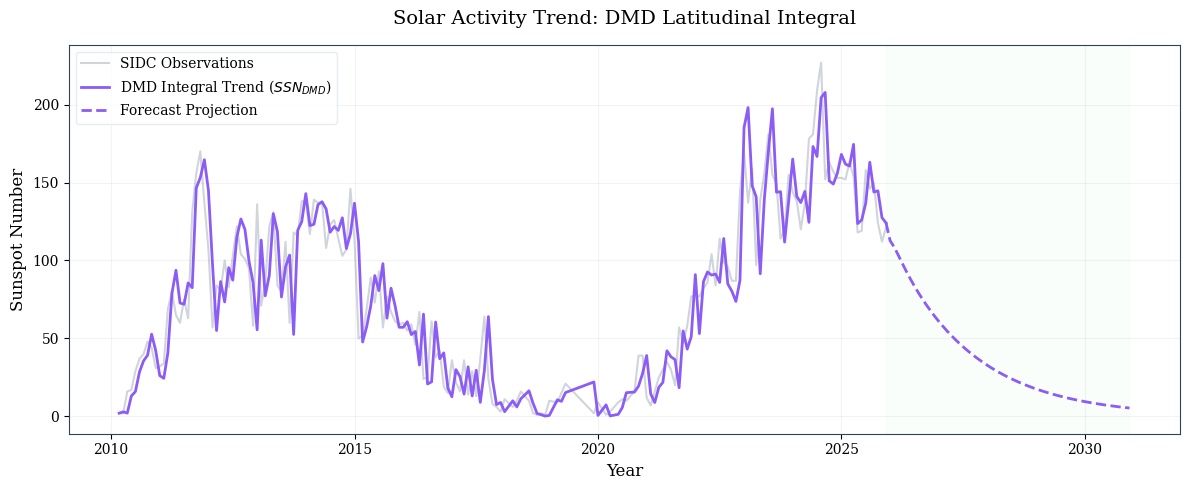

In [13]:
hist_len = len(monthly_hist)
true_ssn = monthly_hist['ssn'].values

# Calculate Relative Errors (MAPE)
kalman_err = np.mean(np.abs(true_ssn - kalman_ssn[:hist_len]) / np.maximum(1, true_ssn)) * 100
dmd_err = np.mean(np.abs(true_ssn - dmd_ssn[:hist_len]) / np.maximum(1, true_ssn)) * 100

print(f"MAPE PVL-Kalman: {kalman_err:.2f}%")
print(f"MAPE DMD: {dmd_err:.2f}%")

# 1. Plot Spörer Migration (DMD Butterfly)
plt.figure(figsize=(12, 6))
dots = butterfly_df
plt.scatter(dots[~dots['is_f']]['y'], dots[~dots['is_f']]['l'], s=dots[~dots['is_f']]['s']*2, c=COLORS['obs'], alpha=0.5, label='Observed (Vectorized)')
plt.scatter(dots[dots['is_f']]['y'], dots[dots['is_f']]['l'], s=dots[dots['is_f']]['s']*2, c=COLORS['dmd'], alpha=0.6, label='DMD Forecast')
plt.axvline(monthly_hist['year_float'].max(), color='#94a3b8', linestyle='--', alpha=0.8)
plt.title("Spörer Latitudinal Migration Reconstruction (DMD)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Latitude [deg]", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('figure_sporer_migration.png', dpi=300)
plt.show()

# 2. Plot SSN PVL-Kalman
plt.figure(figsize=(12, 5))
plt.plot(monthly_hist['year_float'], true_ssn, color=COLORS['obs'], alpha=0.3, label='SIDC Observations')
plt.plot(full_yf[:hist_len], kalman_ssn[:hist_len], color=COLORS['kalman'], lw=2, label='PVL-Kalman Trend ($SSN_{PVLK}$)')
plt.plot(full_yf[hist_len-1:], kalman_ssn[hist_len-1:], color=COLORS['kalman'], lw=2, ls='--', label='Forecast Projection')
plt.axvspan(monthly_hist['year_float'].max(), full_yf.max(), color=COLORS['future_bg'], alpha=0.4)
plt.title("Solar Activity Trend: PVL + Adaptive Kalman Filter", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sunspot Number", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('figure_ssn_kalman.png', dpi=300)
plt.show()

# 3. Plot SSN DMD
plt.figure(figsize=(12, 5))
plt.plot(monthly_hist['year_float'], true_ssn, color=COLORS['obs'], alpha=0.3, label='SIDC Observations')
plt.plot(full_yf[:hist_len], dmd_ssn[:hist_len], color=COLORS['dmd'], lw=2, label='DMD Integral Trend ($SSN_{DMD}$)')
plt.plot(full_yf[hist_len-1:], dmd_ssn[hist_len-1:], color=COLORS['dmd'], lw=2, ls='--', label='Forecast Projection')
plt.axvspan(monthly_hist['year_float'].max(), full_yf.max(), color=COLORS['future_bg'], alpha=0.4)
plt.title("Solar Activity Trend: DMD Latitudinal Integral", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sunspot Number", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('figure_ssn_dmd.png', dpi=300)
plt.show()

## 6. Spörer Diagram: Latitudinal Migration Analysis

The Butterfly diagram demonstrates the descent of sunspot production towards the solar equator, modeled via the Koopman Operator.

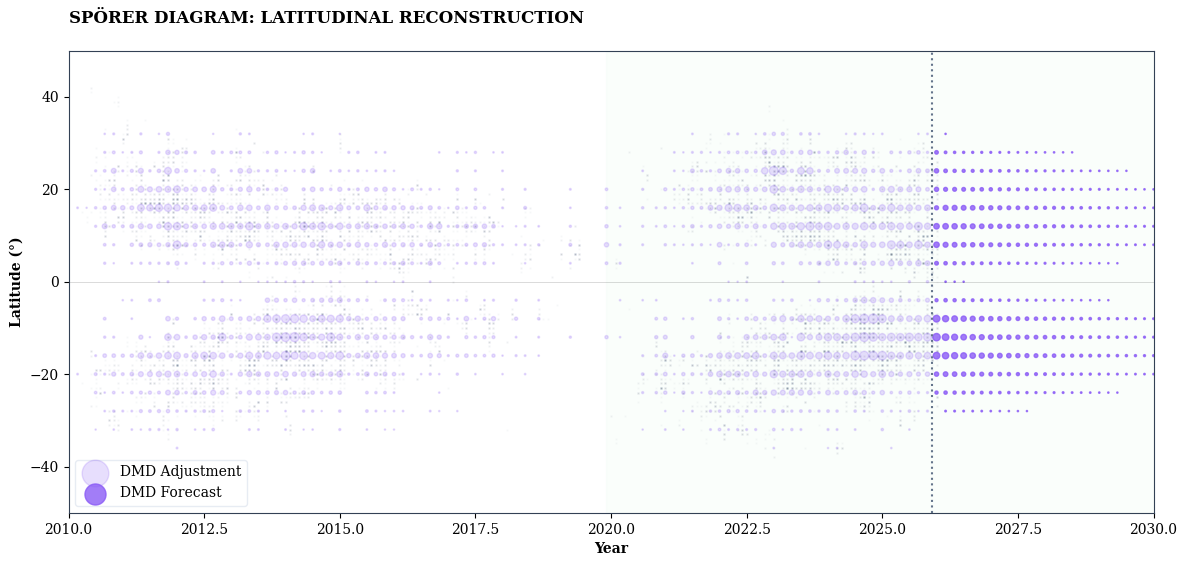

In [14]:
plt.figure(figsize=(14, 6))
plt.scatter(df['date'].dt.year + df['date'].dt.month/12, df['lat'], s=0.5, color=COLORS['obs'], alpha=0.03)
adj = butterfly_df[~butterfly_df['is_f']]
fct = butterfly_df[butterfly_df['is_f']]
plt.scatter(adj['y'], adj['l'], s=adj['s']*1.5, color=COLORS['dmd'], alpha=0.2, label='DMD Adjustment')
plt.scatter(fct['y'], fct['l'], s=fct['s']*1.5, color=COLORS['dmd'], alpha=0.8, label='DMD Forecast')

plt.axvline(monthly_hist['year_float'].max(), color='#64748b', ls=':', lw=1.5)
plt.axvspan(2019.9, full_yf[-1], color=COLORS['future_bg'], alpha=0.3, zorder=-1)
plt.axhline(0, color='black', lw=0.5, alpha=0.2)
plt.title('SPÖRER DIAGRAM: LATITUDINAL RECONSTRUCTION', loc='left', fontweight='bold', pad=20)
plt.ylabel('Latitude (°)', fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.xlim(2010, 2030); plt.ylim(-50, 50)
plt.legend(loc='lower left', markerscale=4, frameon=True)
plt.savefig('figure_sporer_migration.png', dpi=300, bbox_inches='tight')
plt.show()